In [18]:

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
import os 


warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid' , palette='husl')
plt.rcParams['figure.dpi']=120
print("import ready")

import ready


In [19]:
#load data 

profiles     = pd.read_csv('../data/outputs/cluster_labels.csv')
courses      = pd.read_csv('../data/raw/courses.csv')
transactions = pd.read_csv('../data/raw/transactions.csv')

transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])

print(f"Profiles     : {profiles.shape}")
print(f"Courses      : {courses.shape}")
print(f"Transactions : {transactions.shape}")
print()
print("Columns in profiles:")
print(profiles.columns.tolist())

Profiles     : (1216, 33)
Courses      : (400, 5)
Transactions : (23141, 4)

Columns in profiles:
['UserID', 'total_courses', 'total_transactions', 'total_spending', 'avg_spending', 'min_spending', 'max_spending', 'avg_course_rating', 'n_categories', 'first_enroll', 'last_enroll', 'preferred_category', 'preferred_level', 'Beginner', 'Intermediate', 'Advanced', 'Age', 'Gender', 'enrollment_frequency', 'recency_days', 'diversity_score', 'category_concentration', 'learning_depth_index', 'beginner_ratio', 'advanced_ratio', 'preferred_category_enc', 'preferred_level_enc', 'Cluster_Raw', 'Cluster', 'SegmentName', 'PCA_1', 'PCA_2', 'SilhouetteVal']


In [20]:
# Check one user — see what information we have to work with
sample_user = profiles['UserID'].iloc[0]
user_info   = profiles[profiles['UserID'] == sample_user].iloc[0]

print(f"Sample User : {sample_user}")
print(f"Cluster     : {int(user_info['Cluster'])}")
print(f"Segment     : {user_info['SegmentName']}")
print(f"Pref Cat    : {user_info['preferred_category']}")
print(f"Pref Level  : {user_info['preferred_level']}")
print(f"Depth Index : {user_info['learning_depth_index']:.3f}")
print(f"Avg Spend   : ${user_info['avg_spending']:.2f}")
print(f"Total Courses: {int(user_info['total_courses'])}")
print()

# Courses this user already took
already_taken = transactions[transactions['UserID'] == sample_user]['CourseID'].tolist()
print(f"Courses already taken : {len(already_taken)}")
print(f"Sample taken IDs      : {already_taken[:5]}")

Sample User : U0001
Cluster     : 1
Segment     : 🚀 Career Climber
Pref Cat    : Technology
Pref Level  : Intermediate
Depth Index : 0.368
Avg Spend   : $167.09
Total Courses: 19

Courses already taken : 19
Sample taken IDs      : ['C0131', 'C0190', 'C0073', 'C0290', 'C0015']


In [21]:
CATEGORIES = [
    'Technology', 'Data Science', 'Business',
    'Design', 'Marketing', 'Finance',
    'Health & Wellness', 'Arts & Creativity'
]
LEVELS = ['Beginner', 'Intermediate', 'Advanced']

SEGMENT_NAMES = {
    0: '🔭 Tech Explorer',
    1: '🚀 Career Climber',
    2: '📚 Deep Specialist',
    3: '🌿 Casual Browser'
}

def recommend_courses(user_id,
                      top_n=8,
                      filter_category=None,
                      filter_level=None):
    """
    Returns top_n course recommendations for a given user.
    
    Scoring weights:
      30% → Cluster peer popularity
      25% → Category preference match
      20% → Level fit
      25% → Course rating quality
    """

    # ── Step 1: Get user profile ──────────────
    user_row = profiles[profiles['UserID'] == user_id]
    if user_row.empty:
        print(f"User {user_id} not found")
        return pd.DataFrame()

    user_row      = user_row.iloc[0]
    user_cluster  = int(user_row['Cluster'])
    pref_cat      = user_row['preferred_category']
    depth_idx     = float(user_row['learning_depth_index'])

    # ── Step 2: Determine target level ────────
    # Based on depth index push user to next level
    if depth_idx < 0.33:
        target_level = 'Beginner'
    elif depth_idx < 0.67:
        target_level = 'Intermediate'
    else:
        target_level = 'Advanced'

    # ── Step 3: Remove already taken courses ──
    taken      = set(transactions[
        transactions['UserID'] == user_id
    ]['CourseID'].tolist())

    candidates = courses[~courses['CourseID'].isin(taken)].copy()

    # ── Step 4: Apply filters if selected ─────
    if filter_category and filter_category != 'All':
        candidates = candidates[
            candidates['CourseCategory'] == filter_category
        ]
    if filter_level and filter_level != 'All':
        candidates = candidates[
            candidates['CourseLevel'] == filter_level
        ]

    if candidates.empty:
        print("No courses match filters. Try widening selection.")
        return pd.DataFrame()

    # ── Step 5: Score 1 — Cluster Popularity ──
    # How popular is this course among same-segment users
    peer_users = profiles[
        profiles['Cluster'] == user_cluster
    ]['UserID'].tolist()

    peer_transactions = transactions[
        transactions['UserID'].isin(peer_users)
    ]

    popularity = (peer_transactions
                  .groupby('CourseID')
                  .size()
                  .reset_index(name='peer_count'))

    candidates = candidates.merge(popularity,
                                  on='CourseID', how='left')
    candidates['peer_count'] = candidates['peer_count'].fillna(0)

    max_pop = candidates['peer_count'].max()
    if max_pop == 0:
        max_pop = 1

    candidates['pop_score'] = candidates['peer_count'] / max_pop

    # ── Step 6: Score 2 — Category Match ──────
    candidates['cat_score'] = (
        candidates['CourseCategory'] == pref_cat
    ).astype(float)

    # ── Step 7: Score 3 — Level Fit ───────────
    candidates['lvl_score'] = (
        candidates['CourseLevel'] == target_level
    ).astype(float)

    # Partial credit for adjacent level
    adjacent = {
        'Beginner'    : 'Intermediate',
        'Intermediate': 'Advanced',
        'Advanced'    : 'Intermediate'
    }
    adj_level = adjacent.get(target_level, '')
    candidates.loc[
        candidates['CourseLevel'] == adj_level, 'lvl_score'
    ] = 0.5

    # ── Step 8: Score 4 — Rating Quality ──────
    candidates['rating_score'] = (
        candidates['CourseRating'] - 1
    ) / 4    # normalise 1-5 → 0-1

    # ── Step 9: Final Weighted Score ──────────
    candidates['RecommendationScore'] = (
        0.30 * candidates['pop_score']    +
        0.25 * candidates['cat_score']    +
        0.20 * candidates['lvl_score']    +
        0.25 * candidates['rating_score']
    )

    # ── Step 10: Rank and Return ──────────────
    top = (candidates
           .sort_values('RecommendationScore', ascending=False)
           .head(top_n)
           .reset_index(drop=True))

    top['Rank']    = top.index + 1
    top['UserID']  = user_id
    top['Segment'] = SEGMENT_NAMES[user_cluster]
    top['TargetLevel'] = target_level

    return top[[
        'Rank', 'UserID', 'CourseID', 'CourseCategory',
        'CourseLevel', 'CourseType', 'CourseRating',
        'RecommendationScore', 'pop_score', 'cat_score',
        'lvl_score', 'rating_score', 'Segment', 'TargetLevel'
    ]]

print("✅ recommend_courses() function defined")


✅ recommend_courses() function defined


In [22]:
# Testing with first user
test_uid = profiles['UserID'].iloc[0]
recs     = recommend_courses(test_uid, top_n=8)

print(f"Recommendations for {test_uid}")
print(f"Segment : {recs['Segment'].iloc[0]}")
print(f"Target Level : {recs['TargetLevel'].iloc[0]}")
print()
print(recs[[
    'Rank', 'CourseID', 'CourseCategory',
    'CourseLevel', 'CourseRating', 'RecommendationScore'
]].to_string(index=False))


Recommendations for U0001
Segment : 🚀 Career Climber
Target Level : Intermediate

 Rank CourseID CourseCategory  CourseLevel  CourseRating  RecommendationScore
    1    C0151     Technology Intermediate           4.7             0.971573
    2    C0254     Technology Intermediate           3.8             0.925000
    3    C0282     Technology Intermediate           4.5             0.901008
    4    C0085     Technology Intermediate           3.9             0.892540
    5    C0123     Technology Intermediate           4.1             0.885685
    6    C0017     Technology Intermediate           4.3             0.878831
    7    C0185     Technology Intermediate           3.6             0.873790
    8    C0055     Technology Intermediate           4.1             0.856653


In [23]:
# Test across different segments
test_users = profiles.drop_duplicates('Cluster') \
                     .groupby('Cluster')['UserID'] \
                     .first().values

print("Testing recommendations across all 4 segments:")
print("=" * 65)

for uid in test_users:
    recs = recommend_courses(uid, top_n=3)
    if recs.empty:
        continue

    user_row = profiles[profiles['UserID'] == uid].iloc[0]
    print(f"\nUser     : {uid}")
    print(f"Segment  : {recs['Segment'].iloc[0]}")
    print(f"Pref Cat : {user_row['preferred_category']}")
    print(f"Target L : {recs['TargetLevel'].iloc[0]}")
    print(f"Top 3 Recommendations:")
    for _, r in recs.iterrows():
        score = r['RecommendationScore']
        print(f"  #{int(r['Rank'])} {r['CourseID']} | "
              f"{r['CourseCategory']:<15} | "
              f"{r['CourseLevel']:<14} | "
              f"⭐{r['CourseRating']} | "
              f"Score: {score:.3f}")
    print("-" * 65)

Testing recommendations across all 4 segments:

User     : U0002
Segment  : 🔭 Tech Explorer
Pref Cat : Design
Target L : Intermediate
Top 3 Recommendations:
  #1 C0127 | Design          | Intermediate   | ⭐4.5 | Score: 0.825
  #2 C0266 | Design          | Intermediate   | ⭐4.4 | Score: 0.813
  #3 C0103 | Design          | Intermediate   | ⭐4.7 | Score: 0.812
-----------------------------------------------------------------

User     : U0001
Segment  : 🚀 Career Climber
Pref Cat : Technology
Target L : Intermediate
Top 3 Recommendations:
  #1 C0151 | Technology      | Intermediate   | ⭐4.7 | Score: 0.972
  #2 C0254 | Technology      | Intermediate   | ⭐3.8 | Score: 0.925
  #3 C0282 | Technology      | Intermediate   | ⭐4.5 | Score: 0.901
-----------------------------------------------------------------

User     : U0028
Segment  : 📚 Deep Specialist
Pref Cat : Technology
Target L : Intermediate
Top 3 Recommendations:
  #1 C0151 | Technology      | Intermediate   | ⭐4.7 | Score: 0.981
  #2

In [24]:
def get_match_reason(row, pref_cat, target_level):
    """
    Explain why this course was recommended
    in plain English
    """
    reasons = []

    if row['cat_score'] == 1.0:
        reasons.append(f"Matches your {pref_cat} interest")

    if row['lvl_score'] == 1.0:
        reasons.append(f"Perfect {target_level} level fit")
    elif row['lvl_score'] == 0.5:
        reasons.append(f"Close to your target level")

    if row['pop_score'] > 0.6:
        reasons.append("Popular in your learner group")

    if row['CourseRating'] >= 4.5:
        reasons.append(f"Highly rated ({row['CourseRating']}★)")
    elif row['CourseRating'] >= 4.0:
        reasons.append(f"Well rated ({row['CourseRating']}★)")

    if not reasons:
        reasons.append("Recommended for your segment")

    return " · ".join(reasons)


def recommend_with_reasons(user_id, top_n=8,
                           filter_category=None,
                           filter_level=None):
    """
    Same as recommend_courses but adds MatchReason column
    """
    recs = recommend_courses(user_id, top_n,
                             filter_category, filter_level)
    if recs.empty:
        return recs

    user_row     = profiles[profiles['UserID'] == user_id].iloc[0]
    pref_cat     = user_row['preferred_category']
    target_level = recs['TargetLevel'].iloc[0]

    recs['MatchReason'] = recs.apply(
        get_match_reason, axis=1,
        args=(pref_cat, target_level)
    )
    return recs


# Test with reasons
test_uid = profiles['UserID'].iloc[10]
recs     = recommend_with_reasons(test_uid, top_n=5)

print(f"Recommendations with reasons for {test_uid}:")
print()
for _, r in recs.iterrows():
    print(f"  #{int(r['Rank'])} {r['CourseID']} | "
          f"{r['CourseCategory']:<15} | "
          f"{r['CourseLevel']:<14} | "
          f"⭐{r['CourseRating']}")
    print(f"     → {r['MatchReason']}")
    print()

Recommendations with reasons for U0014:

  #1 C0381 | Technology      | Beginner       | ⭐4.7
     → Matches your Technology interest · Perfect Beginner level fit · Popular in your learner group · Highly rated (4.7★)

  #2 C0386 | Technology      | Beginner       | ⭐4.5
     → Matches your Technology interest · Perfect Beginner level fit · Popular in your learner group · Highly rated (4.5★)

  #3 C0027 | Technology      | Beginner       | ⭐4.5
     → Matches your Technology interest · Perfect Beginner level fit · Popular in your learner group · Highly rated (4.5★)

  #4 C0300 | Technology      | Beginner       | ⭐5.0
     → Matches your Technology interest · Perfect Beginner level fit · Popular in your learner group · Highly rated (5.0★)

  #5 C0205 | Technology      | Beginner       | ⭐4.9
     → Matches your Technology interest · Perfect Beginner level fit · Popular in your learner group · Highly rated (4.9★)



In [25]:
def recommend_new_user(goal, category, level, top_n=8):
    """
    For users with no history.
    Uses 3 onboarding answers to give first recommendations.
    
    goal     : 'Career' / 'Skill' / 'Hobby'
    category : any from CATEGORIES list
    level    : 'Beginner' / 'Intermediate' / 'Advanced'
    """

    print(f"New User Profile:")
    print(f"  Goal     : {goal}")
    print(f"  Category : {category}")
    print(f"  Level    : {level}")
    print()

    # Filter by category and level preference
    candidates = courses[
        (courses['CourseCategory'] == category) &
        (courses['CourseLevel']    == level)
    ].copy()

    # If too few results, relax level filter
    if len(candidates) < top_n:
        candidates = courses[
            courses['CourseCategory'] == category
        ].copy()

    # For new users rank purely by rating
    candidates = (candidates
                  .sort_values('CourseRating', ascending=False)
                  .head(top_n)
                  .reset_index(drop=True))

    candidates['Rank']   = candidates.index + 1
    candidates['Reason'] = 'Top rated in your chosen category'

    print(f"Top {top_n} recommendations for new user:")
    print(candidates[[
        'Rank', 'CourseID', 'CourseCategory',
        'CourseLevel', 'CourseRating'
    ]].to_string(index=False))

    return candidates


# Test cold start
recommend_new_user(
    goal='Career',
    category='Data Science',
    level='Beginner',
    top_n=5
)

New User Profile:
  Goal     : Career
  Category : Data Science
  Level    : Beginner

Top 5 recommendations for new user:
 Rank CourseID CourseCategory CourseLevel  CourseRating
    1    C0183   Data Science    Beginner           5.0
    2    C0359   Data Science    Beginner           4.8
    3    C0136   Data Science    Beginner           4.7
    4    C0313   Data Science    Beginner           4.7
    5    C0317   Data Science    Beginner           4.7


,CourseID,CourseCategory,CourseType,CourseLevel,CourseRating,Rank,Reason
0,C0183,Data Science,Hybrid,Beginner,5.0,1,Top rated in your chosen category
1,C0359,Data Science,Self-Paced,Beginner,4.8,2,Top rated in your chosen category
2,C0136,Data Science,Video,Beginner,4.7,3,Top rated in your chosen category
3,C0313,Data Science,Live,Beginner,4.7,4,Top rated in your chosen category
4,C0317,Data Science,Hybrid,Beginner,4.7,5,Top rated in your chosen category


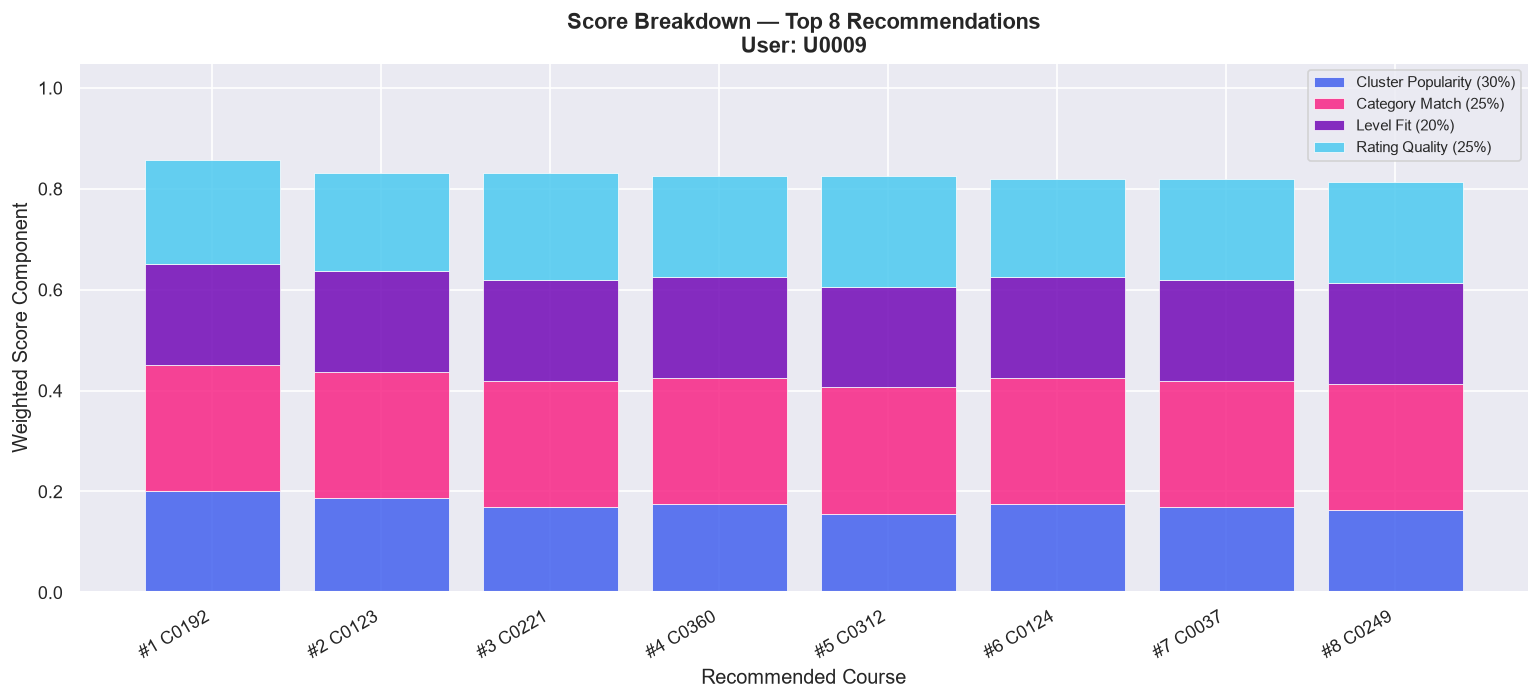

Saved ✅


In [26]:
# Show how each component contributed to score
test_uid = profiles['UserID'].iloc[5]
recs     = recommend_with_reasons(test_uid, top_n=8)

labels = [f"#{int(r['Rank'])} {r['CourseID']}"
          for _, r in recs.iterrows()]

fig, ax = plt.subplots(figsize=(13, 6))

components = [
    ('Cluster Popularity (30%)', 'pop_score',    '#4361ee', 0.30),
    ('Category Match (25%)',     'cat_score',    '#f72585', 0.25),
    ('Level Fit (20%)',          'lvl_score',    '#7209b7', 0.20),
    ('Rating Quality (25%)',     'rating_score', '#4cc9f0', 0.25),
]

bottom = np.zeros(len(recs))
for name, col, color, weight in components:
    values = recs[col].values * weight
    ax.bar(labels, values, bottom=bottom,
           label=name, color=color, alpha=0.85,
           edgecolor='white', linewidth=0.5)
    bottom += values

ax.set_title(f'Score Breakdown — Top 8 Recommendations\nUser: {test_uid}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Recommended Course')
ax.set_ylabel('Weighted Score Component')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/14_score_breakdown.png', dpi=150)
plt.show()
print("Saved ✅")

Recommendation Quality Analysis

Sample size     : 100 users
Avg Rec Score   : 0.878
Avg Rating      : 4.44 ★
Category Match  : 99.0%
Level Match     : 98.6%
Peer Popularity : 72.8%


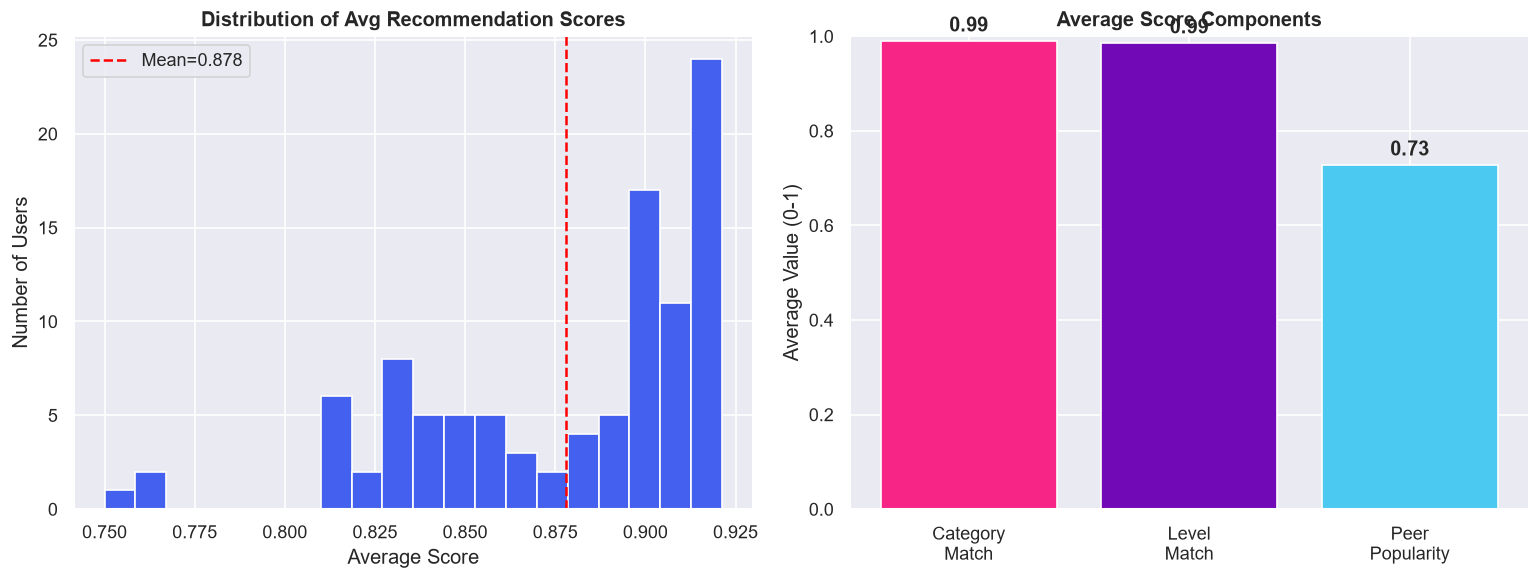

Saved ✅


In [27]:
# Check overall quality of recommendations
print("Recommendation Quality Analysis")
print("=" * 50)

# Sample 100 users
sample_users = profiles['UserID'].sample(100, random_state=42)
all_scores   = []

for uid in sample_users:
    recs = recommend_courses(uid, top_n=5)
    if not recs.empty:
        all_scores.append({
            'UserID'      : uid,
            'AvgScore'    : recs['RecommendationScore'].mean(),
            'AvgRating'   : recs['CourseRating'].mean(),
            'AvgCatMatch' : recs['cat_score'].mean(),
            'AvgLvlMatch' : recs['lvl_score'].mean(),
            'AvgPop'      : recs['pop_score'].mean(),
        })

quality_df = pd.DataFrame(all_scores)

print(f"\nSample size     : {len(quality_df)} users")
print(f"Avg Rec Score   : {quality_df['AvgScore'].mean():.3f}")
print(f"Avg Rating      : {quality_df['AvgRating'].mean():.2f} ★")
print(f"Category Match  : {quality_df['AvgCatMatch'].mean()*100:.1f}%")
print(f"Level Match     : {quality_df['AvgLvlMatch'].mean()*100:.1f}%")
print(f"Peer Popularity : {quality_df['AvgPop'].mean()*100:.1f}%")

# Plot score distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(quality_df['AvgScore'], bins=20,
             color='#4361ee', edgecolor='white')
axes[0].set_title('Distribution of Avg Recommendation Scores',
                  fontweight='bold')
axes[0].set_xlabel('Average Score')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(quality_df['AvgScore'].mean(),
                color='red', linestyle='--',
                label=f"Mean={quality_df['AvgScore'].mean():.3f}")
axes[0].legend()

metrics = ['AvgCatMatch', 'AvgLvlMatch', 'AvgPop']
labels  = ['Category\nMatch', 'Level\nMatch', 'Peer\nPopularity']
values  = [quality_df[m].mean() for m in metrics]
colors  = ['#f72585', '#7209b7', '#4cc9f0']

axes[1].bar(labels, values, color=colors, edgecolor='white')
axes[1].set_title('Average Score Components', fontweight='bold')
axes[1].set_ylabel('Average Value (0-1)')
axes[1].set_ylim(0, 1)
for i, (l, v) in enumerate(zip(labels, values)):
    axes[1].text(i, v + 0.02, f'{v:.2f}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/15_recommendation_quality.png', dpi=150)
plt.show()
print("Saved ✅")

In [28]:
print("Generating recommendations for all users...")
print("This may take 1-2 minutes...")
print()

all_recommendations = []
failed_users        = []

for i, uid in enumerate(profiles['UserID']):
    try:
        recs = recommend_with_reasons(uid, top_n=8)
        if not recs.empty:
            all_recommendations.append(recs)
    except Exception as e:
        failed_users.append(uid)

    # Progress update every 200 users
    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{len(profiles)} users...")

# Combine all
final_recs = pd.concat(all_recommendations, ignore_index=True)

print()
print(f"✅ Complete!")
print(f"Total recommendations : {len(final_recs):,}")
print(f"Users covered         : {final_recs['UserID'].nunique():,}")
print(f"Failed users          : {len(failed_users)}")
print(f"Avg score             : {final_recs['RecommendationScore'].mean():.3f}")

Generating recommendations for all users...
This may take 1-2 minutes...

  Processed 200/1216 users...
  Processed 400/1216 users...
  Processed 600/1216 users...
  Processed 800/1216 users...
  Processed 1000/1216 users...
  Processed 1200/1216 users...

✅ Complete!
Total recommendations : 9,728
Users covered         : 1,216
Failed users          : 0
Avg score             : 0.857


In [ ]:
os.makedirs('../data/outputs', exist_ok=True)

# Save all recommendations
final_recs.to_csv(
    '../data/outputs/recommendations.csv',
    index=False
)

# Save quality metrics
quality_df.to_csv(
    '../data/outputs/recommendation_quality.csv',
    index=False
)


print()
print("Files saved:")
print("  data/outputs/recommendations.csv        ✅")
print("  data/outputs/recommendation_quality.csv ✅")
print()
print("Charts saved:")
print("  reports/figures/14_score_breakdown.png  ✅")
print("  reports/figures/15_rec_quality.png      ✅")
print()
print(f"Total recommendations : {len(final_recs):,}")
print(f"Users covered         : {final_recs['UserID'].nunique():,}")
print(f"Avg rec score         : {final_recs['RecommendationScore'].mean():.3f}")
print()



Files saved:
  data/outputs/recommendations.csv        ✅
  data/outputs/recommendation_quality.csv ✅

Charts saved:
  reports/figures/14_score_breakdown.png  ✅
  reports/figures/15_rec_quality.png      ✅

Total recommendations : 9,728
Users covered         : 1,216
Avg rec score         : 0.857

